In [ ]:
import pandas as pd
from google.colab import files
import io

print("Por favor, selecciona tus archivos CSV desde tu navegador:")
uploaded = files.upload()

all_dfs = []

for fn in uploaded.keys():
  print(f"Se cargó el archivo '{fn}'")
  # Leer el archivo CSV con pandas, especificando el delimitador de punto y coma
  # y usando io.StringIO para leer desde el contenido subido
  temp_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), sep=',')
  all_dfs.append(temp_df)

# Concatenar todos los DataFrames en uno solo
df = pd.concat(all_dfs, ignore_index=True)

print("Las primeras 10 filas de tu DataFrame combinado son:")
display(df.head(10))

Por favor, selecciona tus archivos CSV desde tu navegador:


Saving IoT_anti_interference_dataset.csv to IoT_anti_interference_dataset (2).csv
Se cargó el archivo 'IoT_anti_interference_dataset (2).csv'
Las primeras 10 filas de tu DataFrame combinado son:


,Device_Type,Environment_Type,Weather_Condition,Distance,Transmission_Power,Frequency_Channel,Packet_Size,Battery_Level,RSSI,SNR,Delivery_Success,Energy_Cost
0,Gateway,Rural,Fog,941.616812,5,5,194,34.925250,-85.562193,-99.992747,0,10
1,Sensor,Urban,Rain,573.933803,20,2,445,92.743706,-64.912921,-72.524369,0,40
2,Gateway,Urban,Clear,506.358215,15,3,201,91.899947,-65.649378,-80.472351,0,30
3,Gateway,Forest,Fog,609.331752,10,5,105,56.267580,-70.120482,-83.735996,0,10
4,Sensor,Indoor,Snow,620.144573,5,2,232,44.329337,-70.555371,-84.402347,0,15
5,Sensor,Forest,Rain,178.601658,15,4,171,44.219863,-48.286380,-54.590364,0,15
6,Gateway,Urban,Clear,689.546773,15,2,293,91.775584,-74.993142,-88.693766,0,30
7,Actuator,Forest,Snow,457.827591,10,5,431,45.978665,-63.648079,-78.066309,0,20
8,Gateway,Forest,Clear,522.208139,15,4,253,60.926421,-66.719716,-79.910196,0,15
9,Gateway,Urban,Rain,40.013438,5,1,128,78.480884,-41.070333,-46.983973,0,15


In [ ]:
# Mostrar la información general del DataFrame
print("Información del DataFrame:")
df.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Device_Type         10000 non-null  object 
 1   Environment_Type    10000 non-null  object 
 2   Weather_Condition   10000 non-null  object 
 3   Distance            10000 non-null  float64
 4   Transmission_Power  10000 non-null  int64  
 5   Frequency_Channel   10000 non-null  int64  
 6   Packet_Size         10000 non-null  int64  
 7   Battery_Level       10000 non-null  float64
 8   RSSI                10000 non-null  float64
 9   SNR                 10000 non-null  float64
 10  Delivery_Success    10000 non-null  int64  
 11  Energy_Cost         10000 non-null  int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 937.6+ KB


In [ ]:
# Mostrar estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas del DataFrame:")
display(df.describe())


Estadísticas descriptivas del DataFrame:


,Distance,Transmission_Power,Frequency_Channel,Packet_Size,Battery_Level,RSSI,SNR,Delivery_Success,Energy_Cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000
mean,504.555806,12.507500,3.006600,273.756200,59.939309,-65.221641,-75.242719,0.0,24.962500
std,286.265545,5.569834,1.411083,130.198885,23.067611,15.171996,15.454231,0.0,15.781508
min,10.009203,5.000000,1.000000,50.000000,20.008377,-105.407010,-117.006331,0.0,5.000000
25%,256.107065,10.000000,2.000000,161.000000,39.977857,-77.507756,-87.589893,0.0,15.000000
50%,503.203594,10.000000,3.000000,273.000000,60.180288,-65.343521,-75.305220,0.0,20.000000
75%,752.513723,16.250000,4.000000,387.000000,79.840428,-52.712328,-62.625729,0.0,30.000000
max,999.892152,20.000000,5.000000,499.000000,99.996556,-28.064073,-34.488182,0.0,60.000000


In [ ]:
# Comprobar valores nulos por columna
print("\nValores nulos por columna:")
display(df.isnull().sum())


Valores nulos por columna:


,0
Device_Type,0
Environment_Type,0
Weather_Condition,0
Distance,0
Transmission_Power,0
Frequency_Channel,0
Packet_Size,0
Battery_Level,0
RSSI,0
SNR,0


In [ ]:
# Mover la columna 'SNR' al final del DataFrame
# pop() elimina la columna y devuelve sus datos; luego se vuelve a añadir al final
if 'SNR' in df.columns:
    snr_column = df.pop('SNR')
    df['SNR'] = snr_column

# Eliminar la columna 'Delivery_Success'
# Usamos errors='ignore' para evitar un KeyError si la columna ya no existe
df = df.drop(columns=['Delivery_Success'], errors='ignore')

print("DataFrame después de reorganizar y eliminar columnas:")
display(df.head())
df.info()

DataFrame después de reorganizar y eliminar columnas:


,Device_Type,Environment_Type,Weather_Condition,Distance,Transmission_Power,Frequency_Channel,Packet_Size,Battery_Level,RSSI,Energy_Cost,SNR
0,Gateway,Rural,Fog,941.616812,5,5,194,34.925250,-85.562193,10,-99.992747
1,Sensor,Urban,Rain,573.933803,20,2,445,92.743706,-64.912921,40,-72.524369
2,Gateway,Urban,Clear,506.358215,15,3,201,91.899947,-65.649378,30,-80.472351
3,Gateway,Forest,Fog,609.331752,10,5,105,56.267580,-70.120482,10,-83.735996
4,Sensor,Indoor,Snow,620.144573,5,2,232,44.329337,-70.555371,15,-84.402347


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Device_Type         10000 non-null  object 
 1   Environment_Type    10000 non-null  object 
 2   Weather_Condition   10000 non-null  object 
 3   Distance            10000 non-null  float64
 4   Transmission_Power  10000 non-null  int64  
 5   Frequency_Channel   10000 non-null  int64  
 6   Packet_Size         10000 non-null  int64  
 7   Battery_Level       10000 non-null  float64
 8   RSSI                10000 non-null  float64
 9   Energy_Cost         10000 non-null  int64  
 10  SNR                 10000 non-null  float64
dtypes: float64(4), int64(4), object(3)
memory usage: 859.5+ KB


In [ ]:
# Eliminar las columnas 'Device_Type', 'Environment_Type' y 'Weather_Condition'
df = df.drop(columns=['Device_Type', 'Environment_Type', 'Weather_Condition'])

print("DataFrame después de eliminar las columnas especificadas:")
display(df.head())
df.info()

DataFrame después de eliminar las columnas especificadas:


,Distance,Transmission_Power,Frequency_Channel,Packet_Size,Battery_Level,RSSI,Energy_Cost,SNR
0,941.616812,5,5,194,34.925250,-85.562193,10,-99.992747
1,573.933803,20,2,445,92.743706,-64.912921,40,-72.524369
2,506.358215,15,3,201,91.899947,-65.649378,30,-80.472351
3,609.331752,10,5,105,56.267580,-70.120482,10,-83.735996
4,620.144573,5,2,232,44.329337,-70.555371,15,-84.402347


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Distance            10000 non-null  float64
 1   Transmission_Power  10000 non-null  int64  
 2   Frequency_Channel   10000 non-null  int64  
 3   Packet_Size         10000 non-null  int64  
 4   Battery_Level       10000 non-null  float64
 5   RSSI                10000 non-null  float64
 6   Energy_Cost         10000 non-null  int64  
 7   SNR                 10000 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 625.1 KB


In [ ]:
# Importar las librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definir las variables independientes (X) y la variable objetivo (y)
X = df[['Distance', 'Transmission_Power', 'Frequency_Channel', 'Packet_Size', 'RSSI','Energy_Cost']]
y = df['SNR']

print("Variables independientes (X) seleccionadas:")
display(X.head())
print("\nVariable objetivo (y) seleccionada:")
display(y.head())

Variables independientes (X) seleccionadas:


,Distance,Transmission_Power,Frequency_Channel,Packet_Size,RSSI,Energy_Cost
0,941.616812,5,5,194,-85.562193,10
1,573.933803,20,2,445,-64.912921,40
2,506.358215,15,3,201,-65.649378,30
3,609.331752,10,5,105,-70.120482,10
4,620.144573,5,2,232,-70.555371,15



Variable objetivo (y) seleccionada:


,SNR
0,-99.992747
1,-72.524369
2,-80.472351
3,-83.735996
4,-84.402347


In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
# Usaremos el 80% para entrenamiento y el 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y: {y_test.shape}")

Tamaño del conjunto de entrenamiento X: (8000, 6)
Tamaño del conjunto de prueba X: (2000, 6)
Tamaño del conjunto de entrenamiento y: (8000,)
Tamaño del conjunto de prueba y: (2000,)


In [ ]:
# Inicializar y entrenar el modelo de Regresión Lineal
model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado.")
print(f"Coeficiente (pendiente): {model.coef_}")
print(f"Intercepción (ordenada al origen): {model.intercept_}")

Modelo de Regresión Lineal entrenado.
Coeficiente (pendiente): [ 4.59677885e-04  3.66644233e-03  8.56711142e-03  1.99845651e-04
  1.00721088e+00 -2.55447567e-03]
Intercepción (ordenada al origen): -9.86078790312871


In [ ]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

print("Primeras 5 predicciones:\n", y_pred[:5])
print("Primeros 5 valores reales:\n", y_test.head().values)

Primeras 5 predicciones:
 [-60.51259237 -42.65914211 -63.51757762 -99.28701828 -62.33525623]
Primeros 5 valores reales:
 [ -59.31388352  -39.75290248  -62.25147241 -103.22499038  -62.28894327]


In [ ]:
# Evaluar el rendimiento del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

Error Absoluto Medio (MAE): 2.5111
Error Cuadrático Medio (MSE): 8.3749
Raíz del Error Cuadrático Medio (RMSE): 2.8939
Coeficiente de Determinación (R^2): 0.9664


In [ ]:
# Mostrar las métricas de rendimiento del modelo
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

Error Absoluto Medio (MAE): 2.5111
Error Cuadrático Medio (MSE): 8.3749
Raíz del Error Cuadrático Medio (RMSE): 2.8939
Coeficiente de Determinación (R^2): 0.9664


In [ ]:
# Calcular el MAPE
# Para evitar la división por cero, se añade un pequeño epsilon si y_test es 0
e = 1e-10  # Pequeño valor para evitar división por cero
mape = np.mean(np.abs((y_test - y_pred) / (y_test + e))) * 100

print(f"Error Porcentual Absoluto Medio (MAPE): {mape:.4f}%")

Error Porcentual Absoluto Medio (MAPE): 3.5205%


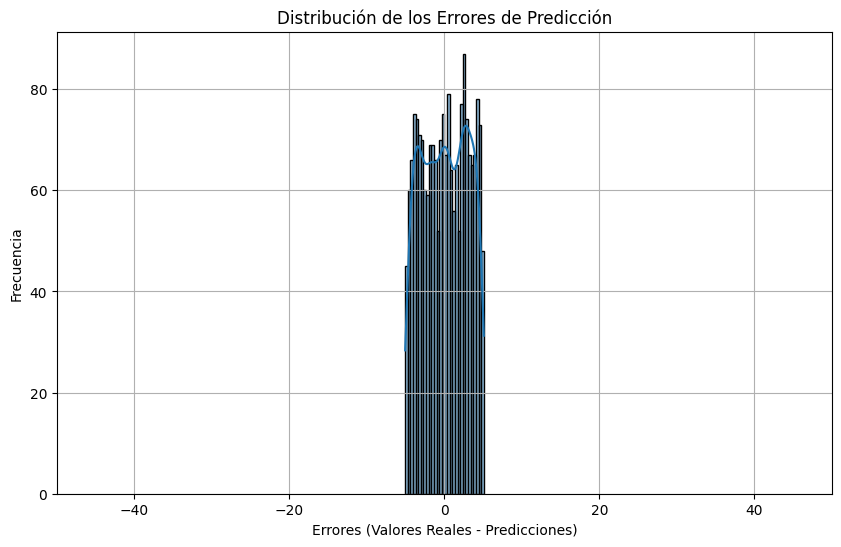

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular los residuos (errores)
residuals = y_test - y_pred

# Crear un histograma de los residuos con KDE
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, edgecolor='black')
plt.title('Distribución de los Errores de Predicción')
plt.xlabel('Errores (Valores Reales - Predicciones)')
plt.ylabel('Frecuencia')
plt.xlim(-50,50) # Establecer los límites del eje x
plt.grid(True)
plt.show()

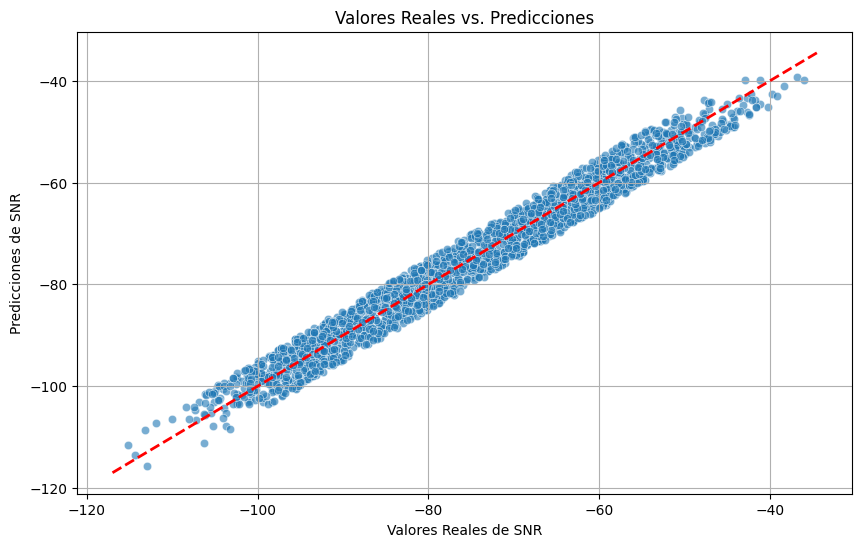

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión de valores reales vs predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Línea de predicción perfecta
plt.title('Valores Reales vs. Predicciones')
plt.xlabel('Valores Reales de SNR')
plt.ylabel('Predicciones de SNR')
plt.grid(True)
plt.show()

### Validación Cruzada para Evaluar la Estabilidad del Modelo

Realizaremos una validación cruzada para evaluar la estabilidad y robustez de nuestro modelo de regresión lineal. Utilizaremos `KFold` para dividir los datos en múltiples pliegues y entrenar y evaluar el modelo en cada uno de ellos.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Número de pliegues para la validación cruzada
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

print(f"Realizando validación cruzada con {n_splits} pliegues...")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model_cv = LinearRegression()
    model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = model_cv.predict(X_test_cv)

    mae_scores.append(mean_absolute_error(y_test_cv, y_pred_cv))
    mse_scores.append(mean_squared_error(y_test_cv, y_pred_cv))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)))
    r2_scores.append(r2_score(y_test_cv, y_pred_cv))

    print(f"-- Pliegue {fold + 1} --")
    print(f"  MAE: {mae_scores[-1]:.4f}")
    print(f"  MSE: {mse_scores[-1]:.4f}")
    print(f"  RMSE: {rmse_scores[-1]:.4f}")
    print(f"  R^2: {r2_scores[-1]:.4f}")

print("\n--- Resultados Promedio de la Validación Cruzada ---")
print(f"MAE Promedio: {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"MSE Promedio: {np.mean(mse_scores):.4f} (+/- {np.std(mse_scores):.4f})")
print(f"RMSE Promedio: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"R^2 Promedio: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")

Realizando validación cruzada con 5 pliegues...
-- Pliegue 1 --
  MAE: 2.5111
  MSE: 8.3749
  RMSE: 2.8939
  R^2: 0.9664
-- Pliegue 2 --
  MAE: 2.4779
  MSE: 8.1852
  RMSE: 2.8610
  R^2: 0.9641
-- Pliegue 3 --
  MAE: 2.4700
  MSE: 8.1989
  RMSE: 2.8634
  R^2: 0.9668
-- Pliegue 4 --
  MAE: 2.4602
  MSE: 8.0880
  RMSE: 2.8439
  R^2: 0.9653
-- Pliegue 5 --
  MAE: 2.4999
  MSE: 8.2838
  RMSE: 2.8782
  R^2: 0.9650

--- Resultados Promedio de la Validación Cruzada ---
MAE Promedio: 2.4838 (+/- 0.0189)
MSE Promedio: 8.2261 (+/- 0.0969)
RMSE Promedio: 2.8681 (+/- 0.0169)
R^2 Promedio: 0.9655 (+/- 0.0010)
